In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA = PROJECT_ROOT / "data" / "processed"

In [2]:
df = pd.read_parquet(DATA)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7079061 entries, 0 to 7079060
Data columns (total 32 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Month              int8          
 1   DayOfWeek          int8          
 2   FlightDate         datetime64[us]
 3   Reporting_Airline  category      
 4   Tail_Number        category      
 5   Origin             category      
 6   OriginState        category      
 7   Dest               category      
 8   DestState          category      
 9   CRSDepTime         int16         
 10  DepDelay           float32       
 11  DepDelayMinutes    float32       
 12  DepDel15           float32       
 13  TaxiOut            float32       
 14  TaxiIn             float32       
 15  CRSArrTime         int16         
 16  ArrDelay           float32       
 17  ArrDelayMinutes    float32       
 18  ArrDel15           float32       
 19  Cancelled          bool          
 20  CancellationCode   category      
 

In [4]:
df.shape

(7079061, 32)

In [5]:
df.head

<bound method NDFrame.head of          Month  DayOfWeek FlightDate Reporting_Airline Tail_Number Origin  \
0            1          1 2024-01-08                9E      N485PX    LGA   
1            1          2 2024-01-09                9E      N912XJ    LGA   
2            1          3 2024-01-10                9E      N918XJ    LGA   
3            1          4 2024-01-11                9E      N490PX    LGA   
4            1          5 2024-01-12                9E      N915XJ    LGA   
...        ...        ...        ...               ...         ...    ...   
7079056     12          7 2024-12-01                YX      N768YX    LGA   
7079057     12          7 2024-12-01                YX      N723YX    ORD   
7079058     12          7 2024-12-01                YX      N654RW    ILM   
7079059     12          7 2024-12-01                YX      N726YX    CHS   
7079060     12          7 2024-12-01                YX      N727YX    LEX   

        OriginState Dest DestState  CRSDepTim

2. Ile jest cancelled / diverted? (to zdecyduje o populacji)

In [6]:
df.columns

Index(['Month', 'DayOfWeek', 'FlightDate', 'Reporting_Airline', 'Tail_Number',
       'Origin', 'OriginState', 'Dest', 'DestState', 'CRSDepTime', 'DepDelay',
       'DepDelayMinutes', 'DepDel15', 'TaxiOut', 'TaxiIn', 'CRSArrTime',
       'ArrDelay', 'ArrDelayMinutes', 'ArrDel15', 'Cancelled',
       'CancellationCode', 'Diverted', 'CRSElapsedTime', 'ActualElapsedTime',
       'AirTime', 'Distance', 'DistanceGroup', 'CarrierDelay', 'WeatherDelay',
       'NASDelay', 'SecurityDelay', 'LateAircraftDelay'],
      dtype='str')

In [10]:
df.loc[:,'Cancelled'].head()

0    False
1    False
2    False
3    False
4    False
Name: Cancelled, dtype: bool

In [11]:
df.iloc[df.loc[:, 'Cancelled'].eq(1)].shape[0] / df.shape[0]

0.013605618033239154

In [12]:
df.iloc[df.loc[:, 'Diverted'].eq(1)].shape[0] / df.shape[0]

0.002471938015507989

In [13]:
df.loc[:, 'Cancelled'].mean()

np.float64(0.013605618033239154)

In [15]:
(df.loc[:, 'Cancelled'] & df.loc[:, 'Diverted']).sum()

np.int64(0)

Nie nakładają się na siebie

Zaobserwowane odsetki: cancelled = **1.3%**, diverted = **0.2%**.

Wniosek: modeluję na lotach **ukończonych**,
bo nie mają zmierzonego ArrDelayMinutes. Odwołania zostają w EDA jako osobny insight.

In [78]:
flights = df.loc[(df.loc[:, 'Cancelled'] == False) & (df.loc[:, 'Diverted'] == False), :].copy().reset_index(drop=True)

In [79]:
flights= flights.drop(columns=['Cancelled', 'Diverted'])
flights.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 6965247 entries, 0 to 6965246
Data columns (total 30 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Month              int8          
 1   DayOfWeek          int8          
 2   FlightDate         datetime64[us]
 3   Reporting_Airline  category      
 4   Tail_Number        category      
 5   Origin             category      
 6   OriginState        category      
 7   Dest               category      
 8   DestState          category      
 9   CRSDepTime         int16         
 10  DepDelay           float32       
 11  DepDelayMinutes    float32       
 12  DepDel15           float32       
 13  TaxiOut            float32       
 14  TaxiIn             float32       
 15  CRSArrTime         int16         
 16  ArrDelay           float32       
 17  ArrDelayMinutes    float32       
 18  ArrDel15           float32       
 19  CancellationCode   category      
 20  CRSElapsedTime     float32       
 

In [80]:
flights.describe()

,Month,DayOfWeek,FlightDate,CRSDepTime,DepDelay,DepDelayMinutes,DepDel15,TaxiOut,TaxiIn,CRSArrTime,ArrDelay,ArrDelayMinutes,ArrDel15,CRSElapsedTime,ActualElapsedTime,AirTime,Distance,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
count,6.965247e+06,6.965247e+06,6965247,6.965247e+06,6.965247e+06,6.965247e+06,6.965247e+06,6.965247e+06,6.965247e+06,6.965247e+06,6.965247e+06,6.965247e+06,6.965247e+06,6.965247e+06,6.965247e+06,6.965247e+06,6.965247e+06,6.965247e+06,1.449964e+06,1.449964e+06,1.449964e+06,1.449964e+06,1.449964e+06
mean,6.597656e+00,3.981580e+00,2024-07-04 02:01:15.316667,1.326149e+03,1.258916e+01,1.589062e+01,2.059882e-01,1.789673e+01,8.318708e+00,1.490323e+03,7.098219e+00,1.589634e+01,2.081715e-01,1.467060e+02,1.412153e+02,1.149999e+02,8.336746e+02,3.808759e+00,2.470631e+01,4.273122e+00,1.353273e+01,1.240914e-01,2.894809e+01
min,1.000000e+00,1.000000e+00,2024-01-01 00:00:00,1.000000e+00,-9.600000e+01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-1.260000e+02,0.000000e+00,0.000000e+00,6.000000e+00,1.500000e+01,5.000000e+00,1.100000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.000000e+00,2.000000e+00,2024-04-07 00:00:00,9.050000e+02,-6.000000e+00,0.000000e+00,0.000000e+00,1.200000e+01,5.000000e+00,1.103000e+03,-1.500000e+01,0.000000e+00,0.000000e+00,9.300000e+01,8.800000e+01,6.300000e+01,3.990000e+02,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,7.000000e+00,4.000000e+00,2024-07-05 00:00:00,1.320000e+03,-2.000000e+00,0.000000e+00,0.000000e+00,1.500000e+01,6.000000e+00,1.515000e+03,-6.000000e+00,0.000000e+00,0.000000e+00,1.300000e+02,1.250000e+02,9.800000e+01,6.800000e+02,3.000000e+00,3.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,2.000000e+00
75%,1.000000e+01,6.000000e+00,2024-10-02 00:00:00,1.735000e+03,9.000000e+00,9.000000e+00,0.000000e+00,2.100000e+01,1.000000e+01,1.925000e+03,9.000000e+00,9.000000e+00,0.000000e+00,1.770000e+02,1.720000e+02,1.450000e+02,1.069000e+03,5.000000e+00,2.200000e+01,0.000000e+00,1.700000e+01,0.000000e+00,3.400000e+01
max,1.200000e+01,7.000000e+00,2024-12-31 00:00:00,2.400000e+03,3.777000e+03,3.777000e+03,1.000000e+00,2.140000e+02,4.440000e+02,2.359000e+03,3.803000e+03,3.803000e+03,1.000000e+00,8.590000e+02,7.920000e+02,7.230000e+02,5.095000e+03,1.100000e+01,3.689000e+03,1.804000e+03,2.700000e+03,1.164000e+03,2.690000e+03
std,3.397296e+00,2.012221e+00,NaN,4.927307e+02,5.582754e+01,5.474790e+01,4.044220e-01,9.664180e+00,6.821793e+00,5.189836e+02,5.799131e+01,5.466117e+01,4.060002e-01,7.239776e+01,7.230781e+01,7.036955e+01,5.963392e+02,2.338321e+00,7.580518e+01,3.387966e+01,3.196907e+01,3.141407e+00,6.359292e+01


In [81]:
flights["y"] = flights.loc[:, "ArrDelay"].ge(15).astype(int)

In [82]:
(flights["y"] == flights["ArrDelay"].ge(15)).mean()

np.float64(1.0)

In [83]:
(flights["y"] == flights["ArrDel15"]).mean()

np.float64(1.0)

In [84]:
flights.loc[:, "y"].describe()
print(flights.loc[:, "y"].value_counts())
print(flights.loc[:, "y"].value_counts(normalize=True))
print(flights.loc[:, "y"].quantile([0.5, 0.85, 0.9, 0.95, 0.99]))

y
0    5515281
1    1449966
Name: count, dtype: int64
y
0    0.791828
1    0.208172
Name: proportion, dtype: float64
0.50    0.0
0.85    1.0
0.90    1.0
0.95    1.0
0.99    1.0
Name: y, dtype: float64


In [85]:
flights.loc[:, "ArrDelay"].describe()
print(flights.loc[:, "ArrDelay"].value_counts())
print(flights.loc[:, "ArrDelay"].value_counts(normalize=True))
print(flights.loc[:, "ArrDelay"].quantile([0.5, 0.85, 0.9, 0.95, 0.99]))

ArrDelay
-12.0      195000
-11.0      194841
-10.0      193190
-13.0      192226
-9.0       189211
            ...  
 1440.0         1
-126.0          1
 1893.0         1
 1314.0         1
 1731.0         1
Name: count, Length: 1887, dtype: int64
ArrDelay
-12.0      2.799614e-02
-11.0      2.797331e-02
-10.0      2.773627e-02
-13.0      2.759787e-02
-9.0       2.716501e-02
               ...     
 1440.0    1.435699e-07
-126.0     1.435699e-07
 1893.0    1.435699e-07
 1314.0    1.435699e-07
 1731.0    1.435699e-07
Name: proportion, Length: 1887, dtype: float64
0.50     -6.0
0.85     26.0
0.90     43.0
0.95     83.0
0.99    215.0
Name: ArrDelay, dtype: float64


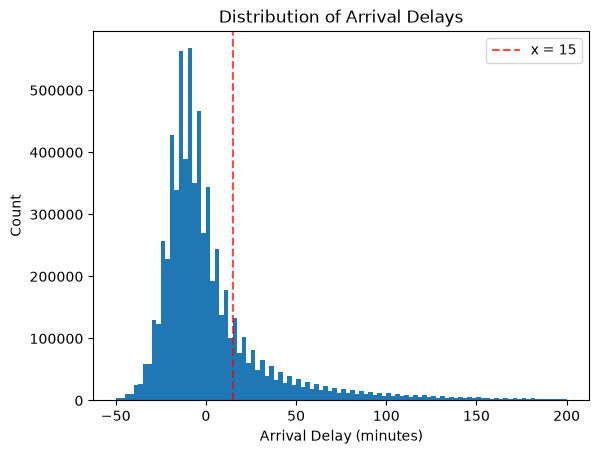

In [86]:
plt.hist(flights.loc[:, "ArrDelay"], bins=100, range=(-50, 200))
plt.axvline(x=15, color='red', linestyle='--', linewidth=1.5, label='x = 15', alpha=0.7)
plt.ylabel("Count")
plt.xlabel("Arrival Delay (minutes)")
plt.title("Distribution of Arrival Delays")
plt.legend()
plt.show()


In [87]:
flights["y"].mean()

np.float64(0.20817151207990184)

**20%** of flights delayed more than 15 min

In [88]:
flights.groupby("Reporting_Airline")["y"].mean().sort_values()

Reporting_Airline
YX    0.140715
HA    0.154548
9E    0.158311
DL    0.172640
OO    0.189980
UA    0.198590
WN    0.206048
MQ    0.208603
G4    0.216718
OH    0.217702
AS    0.220720
NK    0.239261
B6    0.255093
AA    0.261340
F9    0.287401
Name: y, dtype: float64

In [89]:
flights.groupby("Month")["y"].mean().sort_values()

Month
10    0.132031
11    0.146696
9     0.155082
2     0.159210
4     0.190579
3     0.208455
12    0.211550
8     0.234670
1     0.240611
6     0.249380
5     0.264134
7     0.296227
Name: y, dtype: float64

In [90]:
flights.groupby("Dest")["y"].mean().sort_values()

Dest
SPN    0.027473
STC    0.062069
PIH    0.077143
TWF    0.090387
EKO    0.096154
         ...   
MGW    0.305556
AVP    0.306226
HGR    0.308772
HOB    0.311213
EWN    0.375000
Name: y, Length: 348, dtype: float64

In [91]:
flights.groupby("Origin")["y"].mean().sort_values()

Origin
GUM    0.045455
PIH    0.061429
EKO    0.063187
BTM    0.068116
SPN    0.068681
         ...   
HGR    0.360140
EWN    0.361702
SCK    0.372320
HTS    0.436893
MGW    0.459459
Name: y, Length: 348, dtype: float64

In [92]:
flights.groupby("Distance")["ArrDelay"].mean().sort_values()

Distance
1687.0    -52.500000
2390.0    -46.000000
2062.0    -32.000000
1646.0    -31.500000
2297.0    -30.500000
             ...    
943.0      86.000000
788.0     105.529411
1409.0    187.000000
103.0     310.000000
11.0      755.000000
Name: ArrDelay, Length: 1621, dtype: float32

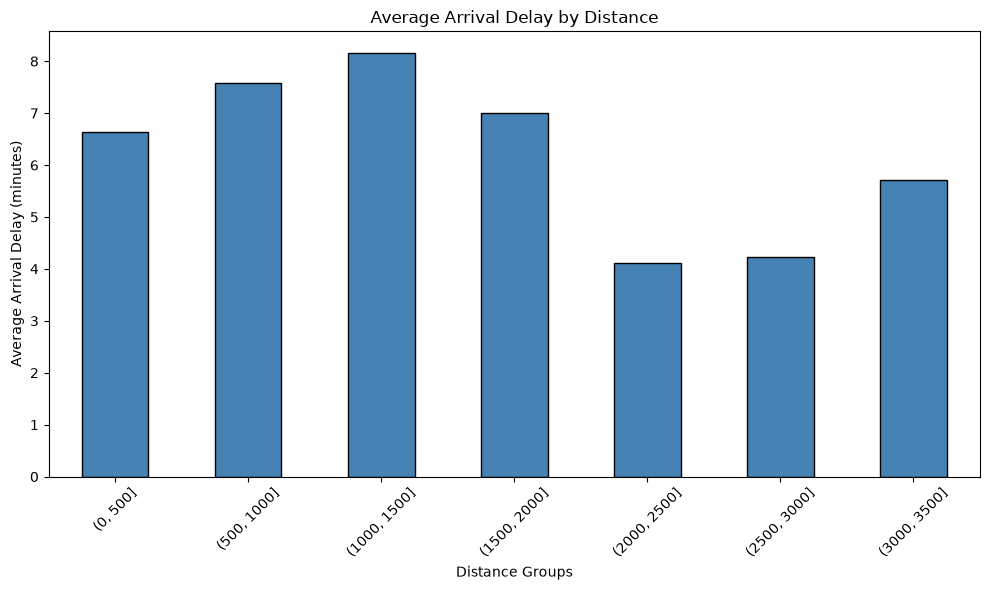

In [93]:
bins = range(0, 3501, 500) 

flights['Distance_Binned'] = pd.cut(flights['Distance'], bins=bins)
delay_by_distance = flights.groupby('Distance_Binned')['ArrDelay'].mean()
delay_by_distance.plot(kind='bar', figsize=(10, 6), color='steelblue', edgecolor='black')

plt.xlabel("Distance Groups")
plt.ylabel("Average Arrival Delay (minutes)")
plt.title("Average Arrival Delay by Distance")
plt.xticks(rotation=45) 
plt.tight_layout()     
plt.show()